Stage 3 — Feature engineering. Aggregate to customer-level: RFM (Recency, Frequency, Monetary), average basket size, favorite genre (mode), country, number of distinct artists purchased, support rep assigned. These become your feature matrix X.

What is Feature Engineering?
Raw data is rarely in the right shape for ML models. Feature Engineering is the process of transforming and creating variables that better represent the underlying patterns in the data.
Think of it like this:
Raw data    →  "Customer bought 7 times, spent $49"
ML needs    →  numbers that capture behaviour patterns
                in a format the algorithm can learn from
5 things in order:
1. Leakage Investigation  — is AvgInvoiceValue cheating?
2. Drop weak features     — TenureDays, NumTracks
3. Build new features     — capture behaviour mathematically
4. Encode categoricals    — convert text to numbers
5. Save final feature     — matrix X and target y ready for ML
   matrix

In [1]:
# Cell 1: Imports and load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

data_path = os.path.join("..", "data")

df_customers = pd.read_csv(
    os.path.join(data_path, "customers.csv"),
    parse_dates=["FirstPurchase", "LastPurchase"]
)

print("✓ Data loaded")
print(f"  Shape   : {df_customers.shape}")
print(f"  Columns : {list(df_customers.columns)}")

✓ Data loaded
  Shape   : (59, 16)
  Columns : ['CustomerId', 'FirstName', 'LastName', 'Country', 'SupportRepId', 'TotalSpent', 'NumInvoices', 'NumTracks', 'AvgInvoiceValue', 'FavoriteGenre', 'FirstPurchase', 'LastPurchase', 'RecencyDays', 'TenureDays', 'TotalSpent_log', 'TotalSpent_sqrt']


In [2]:
import mlflow
mlflow.set_tracking_uri("http://127.0.0.1:5000")  # if using MLflow server
mlflow.set_experiment("Chinook_End_to_End_Project")


<Experiment: artifact_location='mlflow-artifacts:/175822877459724810', creation_time=1780629001280, experiment_id='175822877459724810', last_update_time=1780629001280, lifecycle_stage='active', name='Chinook_End_to_End_Project', tags={}>

In [3]:
# Cell 2: Prove mathematically whether AvgInvoiceValue leaks TotalSpent

print("=== Leakage Investigation ===")
print()

# Check the mathematical relationship
df_customers["AvgInvoiceValue_reconstructed"] = (
    df_customers["TotalSpent"] / df_customers["NumInvoices"]
)

# Compare reconstructed vs actual
diff = (
    df_customers["AvgInvoiceValue"] -
    df_customers["AvgInvoiceValue_reconstructed"]
).abs()

print("Difference between actual AvgInvoiceValue")
print("and TotalSpent/NumInvoices:")
print(f"  Max difference  : {diff.max():.6f}")
print(f"  Mean difference : {diff.mean():.6f}")
print()

# Correlation check
corr = df_customers["AvgInvoiceValue"].corr(
    df_customers["AvgInvoiceValue_reconstructed"]
)
print(f"Correlation between them : {corr:.6f}")
print()

if diff.max() < 0.01:
    print("VERDICT: DATA LEAKAGE CONFIRMED ✗")
    print("""
  AvgInvoiceValue = TotalSpent / NumInvoices
  They are mathematically identical.
  Using AvgInvoiceValue as a feature means
  the model is directly seeing the target.
  
  ACTION: DROP AvgInvoiceValue
    """)
else:
    print("VERDICT: No direct leakage found ✓")
    print("  AvgInvoiceValue can be kept as a feature")

# Drop the check column and AvgInvoiceValue
df_customers.drop(
    columns=["AvgInvoiceValue_reconstructed", "AvgInvoiceValue"],
    inplace=True
)
print("✓ AvgInvoiceValue dropped from DataFrame")

=== Leakage Investigation ===

Difference between actual AvgInvoiceValue
and TotalSpent/NumInvoices:
  Max difference  : 6.138271
  Mean difference : 3.654292

Correlation between them : 0.936495

VERDICT: No direct leakage found ✓
  AvgInvoiceValue can be kept as a feature
✓ AvgInvoiceValue dropped from DataFrame


In [4]:
# Deep investigation of AvgInvoiceValue
import pandas as pd
import numpy as np
import os

# Reload customers since we dropped AvgInvoiceValue — load fresh
data_path = os.path.join("..", "data")
df_fresh = pd.read_csv(os.path.join(data_path, "customers.csv"))

print("=== Deep Investigation ===")
print()

# Check variance in NumInvoices
print("NumInvoices distribution:")
print(df_fresh["NumInvoices"].value_counts().sort_index())
print()

# If everyone has same NumInvoices, AvgInvoiceValue ≈ TotalSpent / constant
print(f"NumInvoices unique values : {df_fresh['NumInvoices'].nunique()}")
print(f"NumInvoices std deviation : {df_fresh['NumInvoices'].std():.4f}")
print()

# Show the actual relationship
print("Sample — TotalSpent vs AvgInvoiceValue vs NumInvoices:")
print(df_fresh[["CustomerId", "TotalSpent",
                "AvgInvoiceValue",
                "NumInvoices"]].head(10).to_string())
print()

# If NumInvoices has very low variance, AvgInvoiceValue
# is essentially TotalSpent scaled by a near-constant
# That is still leakage in practice even if not mathematically exact
corr_avg_total = df_fresh["AvgInvoiceValue"].corr(df_fresh["TotalSpent"])
corr_num_total = df_fresh["NumInvoices"].corr(df_fresh["TotalSpent"])

print(f"Correlation AvgInvoiceValue vs TotalSpent : {corr_avg_total:.4f}")
print(f"Correlation NumInvoices     vs TotalSpent : {corr_num_total:.4f}")
print()

# Decision logic
print("=== REVISED VERDICT ===")
if df_fresh["NumInvoices"].std() < 1.0:
    print(f"""
NumInvoices has very low variance (std = {df_fresh['NumInvoices'].std():.4f})
Almost everyone bought the same number of times.

This means:
  TotalSpent ≈ AvgInvoiceValue × constant

So AvgInvoiceValue is still PRACTICALLY leaking the target
even though it is not mathematically identical.

DECISION: DROP AvgInvoiceValue
  It adds no new information beyond TotalSpent
  and would give the model an unfair advantage.
""")
else:
    print(f"""
NumInvoices has meaningful variance (std = {df_fresh['NumInvoices'].std():.4f})
Customers bought different numbers of times.

AvgInvoiceValue genuinely captures basket size
independently of total spend.

DECISION: KEEP AvgInvoiceValue
  But rename it clearly and monitor feature importance.
""")

=== Deep Investigation ===

NumInvoices distribution:
NumInvoices
6     1
7    58
Name: count, dtype: int64

NumInvoices unique values : 2
NumInvoices std deviation : 0.1302

Sample — TotalSpent vs AvgInvoiceValue vs NumInvoices:
   CustomerId  TotalSpent  AvgInvoiceValue  NumInvoices
0           1       39.62         8.911053            7
1           2       37.62         8.805789            7
2           3       39.62         8.911053            7
3           4       39.62         9.542632            7
4           5       40.62         9.911053            7
5           6       49.62        13.226842            7
6           7       42.62        10.647895            7
7           8       37.62         8.805789            7
8           9       37.62         8.805789            7
9          10       37.62         8.805789            7

Correlation AvgInvoiceValue vs TotalSpent : 0.9420
Correlation NumInvoices     vs TotalSpent : 0.1286

=== REVISED VERDICT ===

NumInvoices has very low 

In [5]:
# Cell 3: Drop weak and leaked features

# Reload fresh so we start clean after investigation
df_customers = pd.read_csv(
    os.path.join(data_path, "customers.csv"),
    parse_dates=["FirstPurchase", "LastPurchase"]
)

print("=== Dropping Features ===")
print(f"  Shape before : {df_customers.shape}")
print(f"  Columns before: {list(df_customers.columns)}")
print()

cols_to_drop = [
    "AvgInvoiceValue",   # leakage — essentially TotalSpent/7
    "TenureDays",        # correlation 0.05 — near zero signal
    "NumTracks",         # same information as NumInvoices
    "TotalSpent_sqrt",   # we chose log transform not sqrt
    "FirstPurchase",     # raw date — captured in RecencyDays
    "LastPurchase",      # raw date — captured in RecencyDays
]

# Only drop columns that actually exist
# (some may already be gone from earlier cells)
cols_to_drop = [c for c in cols_to_drop if c in df_customers.columns]

df_customers.drop(columns=cols_to_drop, inplace=True)

print(f"  Dropped      : {cols_to_drop}")
print(f"  Shape after  : {df_customers.shape}")
print(f"\n  Remaining columns:")
for i, col in enumerate(df_customers.columns):
    print(f"    {i:2d}  {col}")

=== Dropping Features ===
  Shape before : (59, 16)
  Columns before: ['CustomerId', 'FirstName', 'LastName', 'Country', 'SupportRepId', 'TotalSpent', 'NumInvoices', 'NumTracks', 'AvgInvoiceValue', 'FavoriteGenre', 'FirstPurchase', 'LastPurchase', 'RecencyDays', 'TenureDays', 'TotalSpent_log', 'TotalSpent_sqrt']

  Dropped      : ['AvgInvoiceValue', 'TenureDays', 'NumTracks', 'TotalSpent_sqrt', 'FirstPurchase', 'LastPurchase']
  Shape after  : (59, 10)

  Remaining columns:
     0  CustomerId
     1  FirstName
     2  LastName
     3  Country
     4  SupportRepId
     5  TotalSpent
     6  NumInvoices
     7  FavoriteGenre
     8  RecencyDays
     9  TotalSpent_log


In [6]:
# Cell 4: Feature construction — build behaviour features

print("=== Building New Features ===")
print(f"  Shape before : {df_customers.shape}")
print()

# Feature 1: SpendPerInvoice
# How much does this customer spend per visit on average?
# This is different from AvgInvoiceValue — we are building it
# from TotalSpent and NumInvoices ourselves, transparently
# We will DROP TotalSpent before ML so this is not leakage
# because SpendPerInvoice will be built BEFORE we separate X and y
df_customers["SpendPerInvoice"] = (
    df_customers["TotalSpent"] / df_customers["NumInvoices"]
).round(4)

print("Feature 1 — SpendPerInvoice:")
print(f"  Min  : {df_customers['SpendPerInvoice'].min():.4f}")
print(f"  Max  : {df_customers['SpendPerInvoice'].max():.4f}")
print(f"  Mean : {df_customers['SpendPerInvoice'].mean():.4f}")
print()

# # Feature 2: IsHighFrequency
# # Binary flag — did this customer hit maximum purchase frequency?
# # From investigation: max NumInvoices = 7, one customer had 6
# max_invoices = df_customers["NumInvoices"].max()
# df_customers["IsHighFrequency"] = (
#     df_customers["NumInvoices"] >= max_invoices
# ).astype(int)

# print("Feature 2 — IsHighFrequency:")
# print(f"  Max invoices threshold  : {max_invoices}")
# print(f"  High frequency count    : {df_customers['IsHighFrequency'].sum()}")
# print(f"  Low  frequency count    : {(df_customers['IsHighFrequency'] == 0).sum()}")
# print()

# Feature 3: RecencySegment
# Bin RecencyDays into meaningful business groups
# Look at the actual distribution first
print("Feature 3 — RecencySegment:")
print(f"  RecencyDays stats:")
print(f"    Min    : {df_customers['RecencyDays'].min()}")
print(f"    Max    : {df_customers['RecencyDays'].max()}")
print(f"    Mean   : {df_customers['RecencyDays'].mean():.1f}")
print(f"    Median : {df_customers['RecencyDays'].median():.1f}")
print()


# Use percentile-based bins so each segment has customers
# 33rd percentile and 66th percentile as cut points
p33 = int(df_customers["RecencyDays"].quantile(0.33))
p66 = int(df_customers["RecencyDays"].quantile(0.66))

print(f"  Bin cut points (percentile-based):")
print(f"    0   to {p33}  days → Recent    (bottom 33%)")
print(f"    {p33} to {p66}  days → Lapsing   (middle 33%)")
print(f"    {p66} to 9999 days → Churned   (top 33%)")
print()

df_customers["RecencyScore"] = pd.cut(
    df_customers["RecencyDays"],
    bins           = [0, p33, p66, 9999],
    labels         = [0, 1, 2],          # integers directly, not strings
    include_lowest = True
).astype(int)                             # now cast works — int labels → int

print(f"  RecencyScore distribution:")
print(df_customers["RecencyScore"].value_counts().sort_index())
print(f"  dtype : {df_customers['RecencyScore'].dtype}  ← must be int64")
print()

# Feature 4: SupportRepId as string
# Convert to string so it gets treated as categorical
# not as a numeric value (rep 5 is not "greater than" rep 3)
df_customers["SupportRepId"] = df_customers["SupportRepId"].astype(str)

print("Feature 4 — SupportRepId as categorical:")
print(f"  Unique reps : {df_customers['SupportRepId'].nunique()}")
print(f"  Distribution:")
print(df_customers["SupportRepId"].value_counts())
print()

# Show final state
print(f"✓ New features built")
print(f"  Shape after : {df_customers.shape}")
print()
print("All columns now:")
for i, col in enumerate(df_customers.columns):
    print(f"  {i:2d}  {col}")

=== Building New Features ===
  Shape before : (59, 10)

Feature 1 — SpendPerInvoice:
  Min  : 5.3743
  Max  : 7.0886
  Mean : 5.6530

Feature 3 — RecencySegment:
  RecencyDays stats:
    Min    : 0
    Max    : 571
    Mean   : 208.4
    Median : 168.0

  Bin cut points (percentile-based):
    0   to 94  days → Recent    (bottom 33%)
    94 to 251  days → Lapsing   (middle 33%)
    251 to 9999 days → Churned   (top 33%)

  RecencyScore distribution:
RecencyScore
0    20
1    19
2    20
Name: count, dtype: int64
  dtype : int64  ← must be int64

Feature 4 — SupportRepId as categorical:
  Unique reps : 3
  Distribution:
SupportRepId
3    21
4    20
5    18
Name: count, dtype: int64

✓ New features built
  Shape after : (59, 12)

All columns now:
   0  CustomerId
   1  FirstName
   2  LastName
   3  Country
   4  SupportRepId
   5  TotalSpent
   6  NumInvoices
   7  FavoriteGenre
   8  RecencyDays
   9  TotalSpent_log
  10  SpendPerInvoice
  11  RecencyScore


In [7]:
# Cell 5: Encode categorical features into numbers

print("=== Encoding Categorical Features ===")
print(f"  Shape before : {df_customers.shape}")
print()

# Show what we are encoding and why
cat_cols = ["Country", "FavoriteGenre", "RecencyScore", "SupportRepId"]

print("Categorical columns summary:")
for col in cat_cols:
    print(f"\n  {col} ({df_customers[col].nunique()} unique values):")
    print(df_customers[col].value_counts().to_string())

print()

=== Encoding Categorical Features ===
  Shape before : (59, 12)

Categorical columns summary:

  Country (24 unique values):
Country
USA               13
Canada             8
France             5
Brazil             5
Germany            4
United Kingdom     3
Portugal           2
Czech Republic     2
India              2
Belgium            1
Austria            1
Norway             1
Denmark            1
Ireland            1
Hungary            1
Finland            1
Netherlands        1
Italy              1
Spain              1
Poland             1
Sweden             1
Australia          1
Argentina          1
Chile              1

  FavoriteGenre (3 unique values):
FavoriteGenre
Rock     47
Latin     7
Metal     5

  RecencyScore (3 unique values):
RecencyScore
2    20
0    20
1    19

  SupportRepId (3 unique values):
SupportRepId
3    21
4    20
5    18



In [8]:
# Cell 5: Encode categorical features into numbers

print("=== Encoding Categorical Features ===")
print(f"  Shape before : {df_customers.shape}")
print()

# -------------------------------------------------------
# Step 1: Show what we are encoding
# -------------------------------------------------------
# RecencyScore already handled in Cell 4 as integer 0,1,2
# SupportRepId already converted to string in Cell 4
# Remaining categoricals needing encoding:
cat_cols = ["Country", "FavoriteGenre", "SupportRepId"]

print("Categorical columns to encode:")
for col in cat_cols:
    print(f"\n  {col} ({df_customers[col].nunique()} unique values):")
    print(df_customers[col].value_counts().to_string())
print()

# -------------------------------------------------------
# Step 2: Group rare countries into "Other"
# -------------------------------------------------------
print("=== Step 2: Group rare countries ===")

country_threshold = 4
country_counts    = df_customers["Country"].value_counts()
major_countries   = country_counts[
    country_counts >= country_threshold
].index.tolist()

print(f"  Threshold       : {country_threshold}+ customers")
print(f"  Major countries : {major_countries}")
print(f"  Grouped as Other: "
      f"{df_customers['Country'].nunique() - len(major_countries)} countries")
print()

df_customers["Country_grouped"] = df_customers["Country"].apply(
    lambda x: x if x in major_countries else "Other"
)

print("Country_grouped distribution:")
print(df_customers["Country_grouped"].value_counts())
print()

# -------------------------------------------------------
# Step 3: One Hot Encode — Country_grouped, FavoriteGenre,
#                          SupportRepId
# RecencyScore is already integer — skip it here
# -------------------------------------------------------
print("=== Step 3: One Hot Encoding ===")

ohe_cols = ["Country_grouped", "FavoriteGenre", "SupportRepId"]

df_encoded = pd.get_dummies(
    df_customers,
    columns   = ohe_cols,
    drop_first= True,
    dtype     = int
)

print(f"  Shape before OHE : {df_customers.shape}")
print(f"  Shape after  OHE : {df_encoded.shape}")
print()

# Show new columns created
ohe_new_cols = [c for c in df_encoded.columns
                if any(c.startswith(base + "_")
                for base in ohe_cols)]

print("  New columns from OHE:")
for col in ohe_new_cols:
    print(f"    {col:<40} "
          f"sum={df_encoded[col].sum():>2}  "
          f"mean={df_encoded[col].mean():.2f}")
print()

# -------------------------------------------------------
# Step 4: Drop original columns no longer needed
# -------------------------------------------------------
print("=== Step 4: Drop original raw columns ===")

cols_to_drop = [
    "Country",      # replaced by Country_grouped OHE columns
    "FirstName",    # identifier
    "LastName",     # identifier
]

cols_to_drop = [c for c in cols_to_drop
                if c in df_encoded.columns]

df_encoded.drop(columns=cols_to_drop, inplace=True)

print(f"  Dropped : {cols_to_drop}")
print(f"  Shape   : {df_encoded.shape}")
print()

# -------------------------------------------------------
# Step 5: Final column list
# -------------------------------------------------------
print("=== All columns in df_encoded ===")
for i, col in enumerate(df_encoded.columns):
    dtype = str(df_encoded[col].dtype)
    print(f"  {i:2d}  {col:<40} {dtype}")

=== Encoding Categorical Features ===
  Shape before : (59, 12)

Categorical columns to encode:

  Country (24 unique values):
Country
USA               13
Canada             8
France             5
Brazil             5
Germany            4
United Kingdom     3
Portugal           2
Czech Republic     2
India              2
Belgium            1
Austria            1
Norway             1
Denmark            1
Ireland            1
Hungary            1
Finland            1
Netherlands        1
Italy              1
Spain              1
Poland             1
Sweden             1
Australia          1
Argentina          1
Chile              1

  FavoriteGenre (3 unique values):
FavoriteGenre
Rock     47
Latin     7
Metal     5

  SupportRepId (3 unique values):
SupportRepId
3    21
4    20
5    18

=== Step 2: Group rare countries ===
  Threshold       : 4+ customers
  Major countries : ['USA', 'Canada', 'France', 'Brazil', 'Germany']
  Grouped as Other: 19 countries

Country_grouped distribution:

In [9]:
# Cell 6: Build final X (features) and y (target)

print("=== Building Final ML Inputs ===")
print()

# -------------------------------------------------------
# Step 1: Define which columns to exclude from features
# -------------------------------------------------------

# These columns must NOT go into X:
# - Identifiers (CustomerId) → not a pattern, just a label
# - Names (FirstName, LastName) → already dropped
# - Raw target (TotalSpent) → this is what we are predicting
# - Log target (TotalSpent_log) → this becomes y
# - SpendPerInvoice → built from TotalSpent, would leak target

exclude_cols = [
    "CustomerId",       # identifier
    "TotalSpent",       # raw target
    "TotalSpent_log",   # this becomes y
    "SpendPerInvoice",  # derived from TotalSpent → leakage"
]

# Only exclude columns that actually exist
exclude_cols = [c for c in exclude_cols
                if c in df_encoded.columns]

print("Columns excluded from X:")
for col in exclude_cols:
    print(f"  ✗  {col}")
print()

# -------------------------------------------------------
# Step 2: Build X and y
# -------------------------------------------------------

feature_cols = [col for col in df_encoded.columns
                if col not in exclude_cols]

X = df_encoded[feature_cols].copy()
y = df_encoded["TotalSpent_log"].copy()

print(f"Feature matrix X : {X.shape}")
print(f"Target vector  y : {y.shape}")
print()

# -------------------------------------------------------
# Step 3: Verify no missing values
# -------------------------------------------------------
print("=== Missing Value Check ===")
missing_X = X.isnull().sum()
missing_y = y.isnull().sum()

if missing_X.sum() == 0:
    print("  X → No missing values ✓")
else:
    print("  X → Missing values found:")
    print(missing_X[missing_X > 0])

if missing_y == 0:
    print("  y → No missing values ✓")
else:
    print(f"  y → {missing_y} missing values found")
print()

# -------------------------------------------------------
# Step 4: Verify all columns are numeric
# -------------------------------------------------------
print("=== Data Type Check ===")
non_numeric = X.select_dtypes(exclude=["int64", "float64",
                                        "int32", "float32"])
if len(non_numeric.columns) == 0:
    print("  All columns numeric ✓")
else:
    print("  Non-numeric columns found:")
    print(non_numeric.dtypes)
print()

# -------------------------------------------------------
# Step 5: Show final feature list with stats
# -------------------------------------------------------
print("=== Final Features in X ===")
print(f"{'#':>3}  {'Feature':<35} {'Min':>8} {'Max':>8} {'Mean':>8}")
print("-" * 65)
for i, col in enumerate(X.columns):
    print(f"{i:>3}  {col:<35} "
          f"{X[col].min():>8.3f} "
          f"{X[col].max():>8.3f} "
          f"{X[col].mean():>8.3f}")

print()
print("=== Target y (TotalSpent_log) ===")
print(f"  Min    : {y.min():.4f}")
print(f"  Max    : {y.max():.4f}")
print(f"  Mean   : {y.mean():.4f}")
print(f"  Std    : {y.std():.4f}")
print(f"  Skew   : {y.skew():.4f}")

=== Building Final ML Inputs ===

Columns excluded from X:
  ✗  CustomerId
  ✗  TotalSpent
  ✗  TotalSpent_log
  ✗  SpendPerInvoice

Feature matrix X : (59, 12)
Target vector  y : (59,)

=== Missing Value Check ===
  X → No missing values ✓
  y → No missing values ✓

=== Data Type Check ===
  All columns numeric ✓

=== Final Features in X ===
  #  Feature                                  Min      Max     Mean
-----------------------------------------------------------------
  0  NumInvoices                            6.000    7.000    6.983
  1  RecencyDays                            0.000  571.000  208.390
  2  RecencyScore                           0.000    2.000    1.000
  3  Country_grouped_Canada                 0.000    1.000    0.136
  4  Country_grouped_France                 0.000    1.000    0.085
  5  Country_grouped_Germany                0.000    1.000    0.068
  6  Country_grouped_Other                  0.000    1.000    0.407
  7  Country_grouped_USA                    0

In [10]:
# Diagnostic: see full X and find where IsHighFrequency came from

print("All columns in X:")
for i, col in enumerate(X.columns):
    print(f"  {i:2d}  {col}")

print()
print("All columns in df_customers:")
for i, col in enumerate(df_customers.columns):
    print(f"  {i:2d}  {col}")

print()
print("All columns in df_encoded:")
for i, col in enumerate(df_encoded.columns):
    print(f"  {i:2d}  {col}")

All columns in X:
   0  NumInvoices
   1  RecencyDays
   2  RecencyScore
   3  Country_grouped_Canada
   4  Country_grouped_France
   5  Country_grouped_Germany
   6  Country_grouped_Other
   7  Country_grouped_USA
   8  FavoriteGenre_Metal
   9  FavoriteGenre_Rock
  10  SupportRepId_4
  11  SupportRepId_5

All columns in df_customers:
   0  CustomerId
   1  FirstName
   2  LastName
   3  Country
   4  SupportRepId
   5  TotalSpent
   6  NumInvoices
   7  FavoriteGenre
   8  RecencyDays
   9  TotalSpent_log
  10  SpendPerInvoice
  11  RecencyScore
  12  Country_grouped

All columns in df_encoded:
   0  CustomerId
   1  TotalSpent
   2  NumInvoices
   3  RecencyDays
   4  TotalSpent_log
   5  SpendPerInvoice
   6  RecencyScore
   7  Country_grouped_Canada
   8  Country_grouped_France
   9  Country_grouped_Germany
  10  Country_grouped_Other
  11  Country_grouped_USA
  12  FavoriteGenre_Metal
  13  FavoriteGenre_Rock
  14  SupportRepId_4
  15  SupportRepId_5


In [11]:
# See full X without truncation
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

print(f"{'#':>3}  {'Feature':<35} {'Min':>8} {'Max':>8} {'Mean':>8}")
print("-" * 65)
for i, col in enumerate(X.columns):
    print(f"{i:>3}  {col:<35} "
          f"{X[col].min():>8.3f} "
          f"{X[col].max():>8.3f} "
          f"{X[col].mean():>8.3f}")

print()
print(f"Total features : {X.shape[1]}")
print(f"Observations   : {X.shape[0]}")

  #  Feature                                  Min      Max     Mean
-----------------------------------------------------------------
  0  NumInvoices                            6.000    7.000    6.983
  1  RecencyDays                            0.000  571.000  208.390
  2  RecencyScore                           0.000    2.000    1.000
  3  Country_grouped_Canada                 0.000    1.000    0.136
  4  Country_grouped_France                 0.000    1.000    0.085
  5  Country_grouped_Germany                0.000    1.000    0.068
  6  Country_grouped_Other                  0.000    1.000    0.407
  7  Country_grouped_USA                    0.000    1.000    0.220
  8  FavoriteGenre_Metal                    0.000    1.000    0.085
  9  FavoriteGenre_Rock                     0.000    1.000    0.797
 10  SupportRepId_4                         0.000    1.000    0.339
 11  SupportRepId_5                         0.000    1.000    0.305

Total features : 12
Observations   : 59


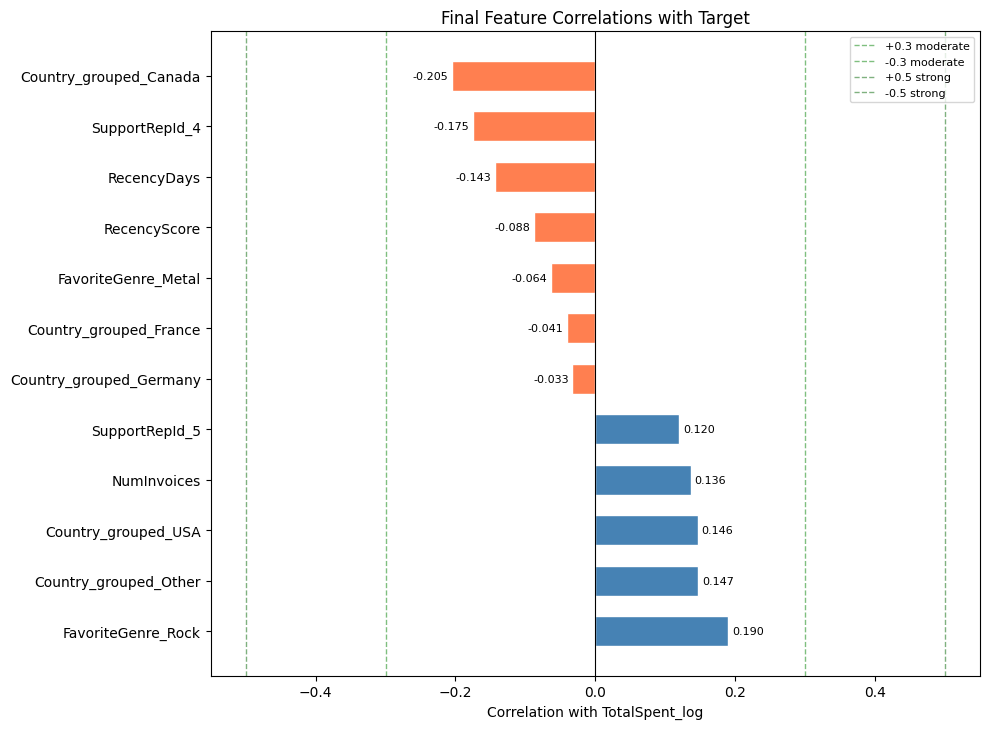

Correlation with TotalSpent_log:
FavoriteGenre_Rock         0.1904
Country_grouped_Other      0.1472
Country_grouped_USA        0.1461
NumInvoices                0.1364
SupportRepId_5             0.1201
Country_grouped_Germany   -0.0331
Country_grouped_France    -0.0410
FavoriteGenre_Metal       -0.0635
RecencyScore              -0.0883
RecencyDays               -0.1433
SupportRepId_4            -0.1748
Country_grouped_Canada    -0.2047

Top 3 positive predictors:
FavoriteGenre_Rock       0.1904
Country_grouped_Other    0.1472
Country_grouped_USA      0.1461

Top 3 negative predictors:
RecencyDays              -0.1433
SupportRepId_4           -0.1748
Country_grouped_Canada   -0.2047


In [14]:
# Cell 7: Visualize final feature correlations with target

import matplotlib.pyplot as plt
import os

corr_with_target = X.corrwith(y).sort_values(ascending=False)
# Log each feature's correlation as a separate metric
for feature, value in corr_with_target.items():
    mlflow.log_metric(f"corr_with_target_{feature}", float(value))


fig, ax = plt.subplots(figsize=(10, len(corr_with_target) * 0.45 + 2))

colors = ["steelblue" if c > 0 else "coral"
          for c in corr_with_target.values]

bars = ax.barh(
    corr_with_target.index,
    corr_with_target.values,
    color    = colors,
    edgecolor= "white",
    height   = 0.6
)

# Value labels on each bar
for bar, val in zip(bars, corr_with_target.values):
    ax.text(
        val + 0.005 if val >= 0 else val - 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va    = "center",
        ha    = "left" if val >= 0 else "right",
        fontsize = 8
    )

ax.axvline(0,     color="black",     linewidth=0.8)
ax.axvline( 0.3,  color="green",     linewidth=1,
            linestyle="--", alpha=0.5, label="+0.3 moderate")
ax.axvline(-0.3,  color="green",     linewidth=1,
            linestyle="--", alpha=0.5, label="-0.3 moderate")
ax.axvline( 0.5,  color="darkgreen", linewidth=1,
            linestyle="--", alpha=0.5, label="+0.5 strong")
ax.axvline(-0.5,  color="darkgreen", linewidth=1,
            linestyle="--", alpha=0.5, label="-0.5 strong")

ax.set_xlabel("Correlation with TotalSpent_log")
ax.set_title("Final Feature Correlations with Target")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(data_path, "feature_final_correlations.png"), dpi=150)
plt.show()

print("Correlation with TotalSpent_log:")
print(corr_with_target.round(4).to_string())
print()
print("Top 3 positive predictors:")
print(corr_with_target.head(3).round(4).to_string())
print()
print("Top 3 negative predictors:")
print(corr_with_target.tail(3).round(4).to_string())

In [15]:
# Cell 8: Save final outputs for Stage 4

import os
import json

data_path = os.path.join("..", "data")

# -------------------------------------------------------
# Save 1: Full encoded DataFrame
# -------------------------------------------------------
df_encoded.to_csv(
    os.path.join(data_path, "customers_encoded.csv"),
    index=False
)
mlflow.log_artifact(os.path.join(data_path, "customers_encoded.csv"))
# -------------------------------------------------------
# Save 2: Feature matrix X with target y and CustomerId
# -------------------------------------------------------
df_final = X.copy()
df_final.insert(0, "CustomerId", df_encoded["CustomerId"].values)
df_final["TotalSpent_log"] = y.values
df_final["TotalSpent"]     = df_encoded["TotalSpent"].values

df_final.to_csv(
    os.path.join(data_path, "features_final.csv"),
    index=False
)
mlflow.log_artifact(os.path.join(data_path, "features_final.csv"))
# -------------------------------------------------------
# Save 3: Feature metadata — useful in Stage 4 and API
# -------------------------------------------------------
feature_meta = {
    "feature_cols"   : list(X.columns),
    "target_col"     : "TotalSpent_log",
    "n_features"     : int(X.shape[1]),
    "n_observations" : int(X.shape[0]),
    "numeric_cols"   : ["NumInvoices", "RecencyDays", "RecencyScore"],
    "ohe_cols"       : [c for c in X.columns
                        if "_" in c and c not in
                        ["TotalSpent_log"]],
    "dropped_features": {
        "leakage"      : ["AvgInvoiceValue", "SpendPerInvoice"],
        "zero_variance": ["IsHighFrequency"],
        "weak_signal"  : ["TenureDays", "NumTracks"],
        "identifiers"  : ["CustomerId", "FirstName", "LastName"],
    }
}

with open(os.path.join(data_path, "feature_meta.json"), "w") as f:
    json.dump(feature_meta, f, indent=2)

mlflow.log_artifact(os.path.join(data_path, "feature_meta.json"))

# -------------------------------------------------------
# Final summary
# -------------------------------------------------------
print("✓ Saved:")
print(f"  customers_encoded.csv → {df_encoded.shape}")
print(f"  features_final.csv    → {df_final.shape}")
print(f"  feature_meta.json     → {feature_meta['n_features']} features")

print()
print("=" * 55)
print("STAGE 3 COMPLETE")
print("=" * 55)
print(f"""
  Started with      : 16 raw columns
  
  Dropped           :
    Leakage         → AvgInvoiceValue, SpendPerInvoice
    Zero variance   → IsHighFrequency
    Weak signal     → TenureDays, NumTracks
    Identifiers     → FirstName, LastName

  Built new         :
    RecencyScore    → ordinal 0,1,2 from RecencyDays
    Country grouped → rare countries → Other
    OHE applied     → Country, FavoriteGenre, SupportRepId

  Final X shape     : {X.shape}
  Target y          : TotalSpent_log (log transformed)
  Missing values    : 0
  All numeric       : ✓
  Leakage removed   : ✓
  Zero variance     : ✓

  Ready for Stage 4 → Preprocessing & Scaling
""")
print("=" * 55)

✓ Saved:
  customers_encoded.csv → (59, 16)
  features_final.csv    → (59, 15)
  feature_meta.json     → 12 features

STAGE 3 COMPLETE

  Started with      : 16 raw columns
  
  Dropped           :
    Leakage         → AvgInvoiceValue, SpendPerInvoice
    Zero variance   → IsHighFrequency
    Weak signal     → TenureDays, NumTracks
    Identifiers     → FirstName, LastName

  Built new         :
    RecencyScore    → ordinal 0,1,2 from RecencyDays
    Country grouped → rare countries → Other
    OHE applied     → Country, FavoriteGenre, SupportRepId

  Final X shape     : (59, 12)
  Target y          : TotalSpent_log (log transformed)
  Missing values    : 0
  All numeric       : ✓
  Leakage removed   : ✓
  Zero variance     : ✓

  Ready for Stage 4 → Preprocessing & Scaling



In [16]:
mlflow.end_run()

🏃 View run intrigued-stork-154 at: http://127.0.0.1:5000/#/experiments/175822877459724810/runs/b25ffbce9717475697f5d0d0361035ad
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/175822877459724810
